# A daļa: Klasterizācija #

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 30 kolonnas


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                   -0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

**Normalizācijas būtība**

*Normalizācija - iezīmes tiek pārvērstas vienā skalā, piemēram, -1 līdz 1. Tā kā klasterizācija grupē punktus pēc attāluma jeb cik tālu viens punkts ir no otra, tad datu grupām (iezīmēm) ar dažādu vērtību skalām , piemēram, 0.0 – 0.2 un 0 – 5000, būs problēma, jo lielākie skaitļi dominēs.*

*Bez normalizācijas:*

- Klasteri veidotos tikai pēc lielākajiem skaitļiem

- Svarīgas iezīmes ar mazu skalu tiktu ignorētas

- Klasteri būtu neloģiski un grūti interpretējami

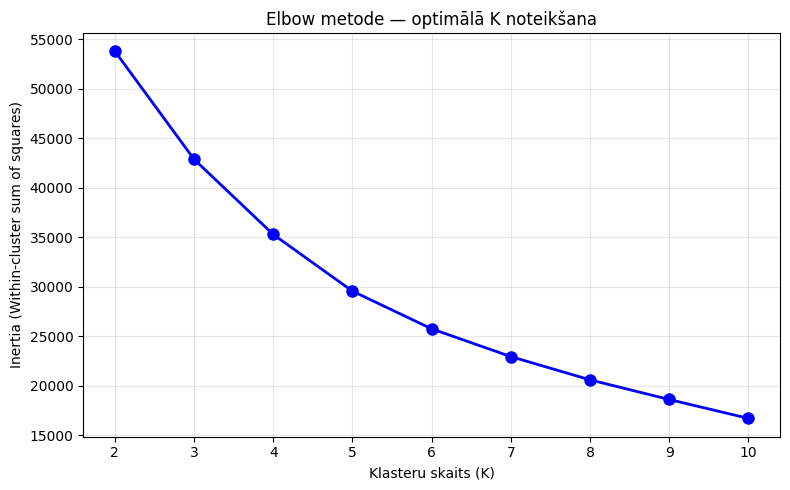

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Elkonis ir vieta, kur līkne pārstāj strauji krist un sāk krist lēnāk — vizuāli izskatās kā elkoņa leņķis.*

| K solis | Kritums | Novērtējums |
|---|---|---|
| K=2 → K=3 | ~11 000 | Ļoti straujš |
| K=3 → K=4 | ~8 000 | Straujš |
| K=4 → K=5 | ~5 000 | Mazāks |
| K=5 → K=6 | ~4 000 | Vēl mazāks |
| K=6 → K=7 | ~2 500 | Jau lēns |
| K=7+ | < 2 000 | Gandrīz līdzens |

*Elkonis ir aptuveni pie **K=4 vai K=5**, kur kritums sāk ievērojami palēnināties.*

*Ieteicams sākt ar **K=4**, jo:*

- Grafiks rāda pirmo nozīmīgo lūzumu tieši tur

-  klasteri ir viegli interpretējami biznesiski

- Pārāk daudz klasteru apgrūtina skaidrojumu

In [5]:
# Izmanto izvēlēto K vērtību (piemēram, 4)
K = 4  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


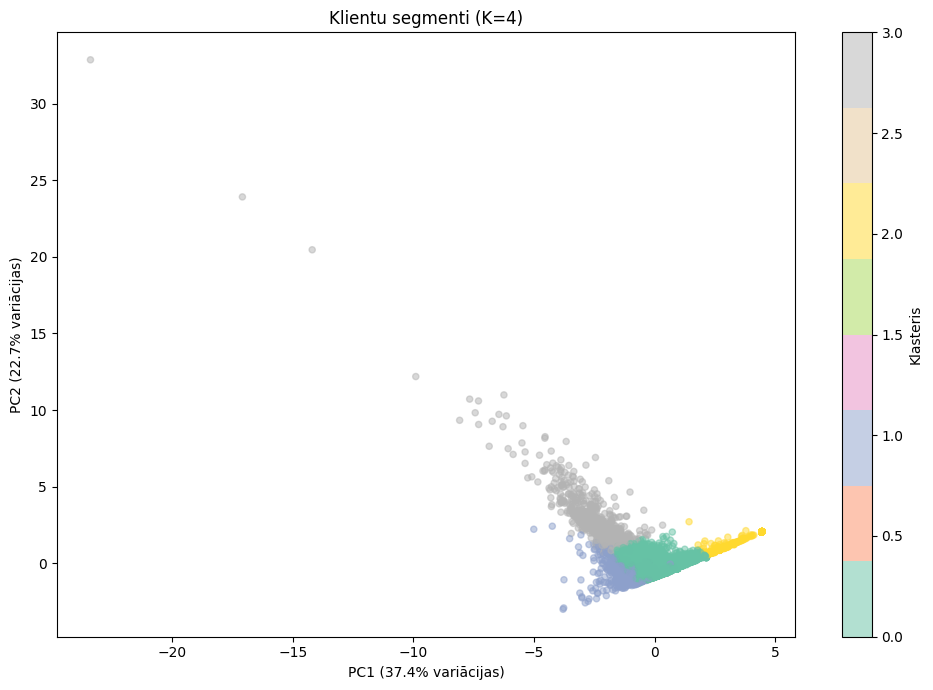

In [6]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          56.28                   13.36   
1                          91.62                   22.46   
2                           1.52                    0.04   
3                         435.57                  319.58   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                         977.18         0.01       0.03        2.28  
1                        1230.94         0.00       0.01       67.76  
2                          47.20         0.18       0.19        0.00  
3                        4859.98         0.01       0.02        6.44  


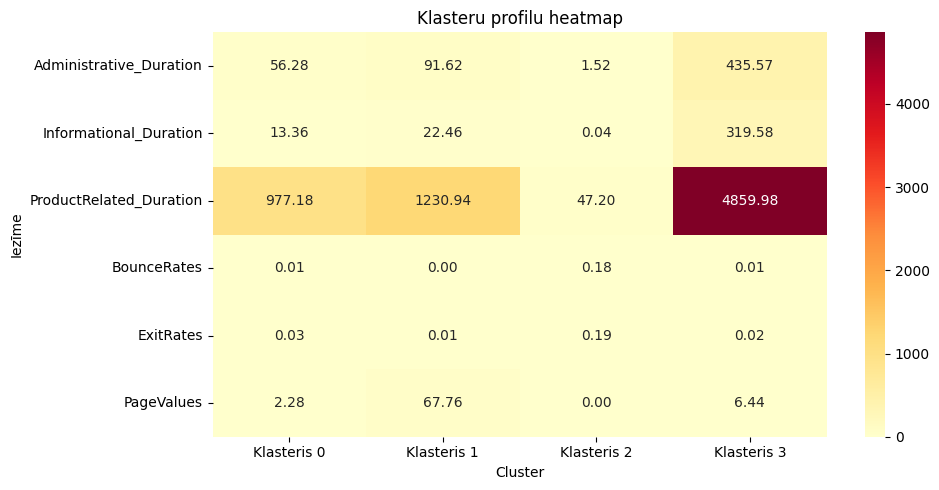

In [7]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)
# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

**Klasteru analīze**

| Klasteris | Nosaukums | Raksturojums | Biznesa darbība |
|---|---|---|---|
| **Klasteris 0** | 🟡 "Interesenti" | Vidējs laiks produktu lapās (977s jeb 16min), zems ExitRate (0.03), bet zems PageValues (2.28) — pārlūko, bet nepērk | Nosūtīt **atgādinājumu vai atlaižu kodu** — viņi ir ieinteresēti, vajag tikai papildu stimulu |
| **Klasteris 1** | 🟢 "Gatavie pircēji" | Augsts laiks produktu lapās (1231s jeb 20min), ļoti zems ExitRate (0.01), **augsts PageValues (67.76)** — aktīvi un iesaistīti | Piedāvāt **upsell vai cross-sell** — viņi jau pērk, var nopirkt vairāk |
| **Klasteris 2** | 🔴 "Garāmgājēji" | Minimāls laiks visur (47s produktos), augsts BounceRate (0.18) un ExitRate (0.19), PageValues = 0 — ierodas un aiziet | Uzlabot **pirmās lapas saturu un ātrumu** — jāpieķer uzmanība pirmajās sekundēs |
| **Klasteris 3** | 🔵 "VIP lietotāji" | Milzīgs laiks visur (4860s produktos, 436s admin), PageValues (6.44) — ļoti dziļa pārlūkošana, iespējams B2B vai lieli pirkumi | Piedāvāt **personalizētu apkalpošanu vai lojalitātes programmu** — šie ir vērtīgākie klienti |

# B daļa: Modeļu novērtēšana

In [8]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus
df = pd.read_csv('shoppers_clean.csv')
y = df['Revenue']
X = df.drop('Revenue', axis=1)

# Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Viena split F1: {single_f1:.3f}")

# Cross-validation (5-fold)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"\n5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Viena split F1: 0.628

5-fold CV F1 scores: [0.65  0.666 0.641 0.554 0.613]
Vidējais F1: 0.625 ± 0.039


**Starpība starp novērtēšanas metodēm ir tikai 0.003, kas ir ļoti maza vērtība. Tas nozīmē, ka modelis ir stabils.**

*Uzticamāks ir **Cross-validation**, jo viens split ir kā eksāmens ar vienu jautājumu (var paveikties), bet Cross-validation ir eksāmens ar 50 jautājumiem (rezultāts ir godīgāks).*

**Standartnovirze (± 0.039)** -> Standartnovirze parāda, cik ļoti svārstās rezultāti starp dažādiem splitiem

| Standartnovirze | Nozīme |
|---|---|
| **Maza (< 0.02)** | Modelis stabils — vienādi strādā uz dažādiem datiem |
| **± 0.039** | Vidēja — nedaudz svārstīgs, bet pieņemami |
| **Liela (> 0.07)** | Modelis nestabils — ļoti atkarīgs no datiem |

*Modelis strādā konsekventi ap 0.625 ar nelielu svārstību. Tas nav izcils rezultāts, bet ir uzticams un stabils.*

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Pipeline — scaler + modelis vienā
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Cross-validation ar pipeline
cv_scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1')
print(f"Pipeline CV F1: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

Pipeline CV F1: 0.621 ± 0.036


**Pipeline nozīme**

- nodrošina, ka visi soļi notiek pareizā secībā un pareizajos datos —> automātiski, katru reizi vienādi;
  
- novērš cilvēka kļūdas un garantē, ka testa dati nekad "neredz" treniņa datus.

*Ja normalizē PIRMS split, tā ir data leakage jeb modelis netieši "zina" kaut ko par testa datiem jau pirms testēšanas.*

**Vienkārsāis vs Pipeline CV**

| | F1 | Std |
|---|---|---|
| **Vienkāršais CV** | 0.625 | ± 0.039 |
| **Pipeline CV** | 0.621 | ± 0.036 |

*Starpība ir tikai 0.004; standartnovirze samazinājās no 0.039 uz 0.036:*

- Šie dati jau bija salīdzinoši tīri

- Pipeline padarīja modeli nedaudz stabilāku

*Pipeline šeit nedeva dramatisku uzlabojumu skaitļos, bet tas ir metodiski pareizi. Reālos projektos, kur dati ir daudz "trokšņaināki", starpība var būt ļoti nozīmīga. Pipeline ir labā prakse vienmēr.*

In [10]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim labākos parametrus
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV — automātiska meklēšana + cross-validation
grid = GridSearchCV(pipe_grid, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Testa F1: {f1_score(y_test, grid.predict(X_test)):.3f}")

Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1: 0.648
Testa F1: 0.625


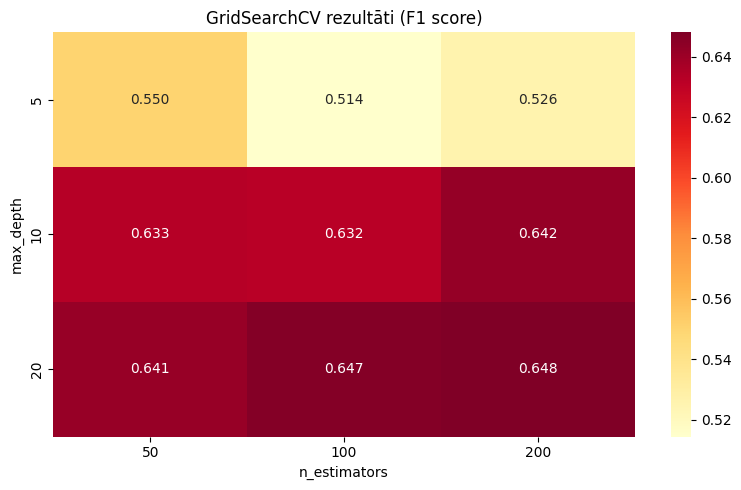

In [11]:
# Vizualizē GridSearch rezultātus
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

import seaborn as sns
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1 score)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

**1.Vai GridSearchCV atrada labākus parametrus nekā manuāli izvēlētie iepriekšējos patstāvīgajos darbos?**

*Jā, bet uzlabojums ir ļoti neliels*

**2.Cik liela ir atšķirība starp labāko un sākotnējo modeli?**

| | max_depth | n_estimators | F1 |
|---|---|---|---|
| **Sākotnējais modelis** | 10 | 100 | 0.625 |
| **GridSearchCV labākais** | 20 | 200 | 0.648 |
| **Starpība** | | | **+0.023** |

**3.Vai atšķirība ir pietiekami liela, lai attaisnotu papildu skaitļošanas laiku?**

*Reālā biznesā pat maza kļūda var nozīmēt tūkstošiem eiro zaudējumus, tāpēc attaisnojas. Ja runa par ātru prototipēšanu, tad nav vērts*